In [1]:
# # Actionable Insights
# 
# This notebook provides actionable insights from the Rossmann Store Sales dataset, detailing specific changes in percentages, numerical values, and visualizations to spot trends over time.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

# Load datasets
train_df = pd.read_csv('interim_train.csv', low_memory=False)
store_df = pd.read_csv('interim_store.csv')
df = pd.merge(train_df, store_df, on='Store')

# Map DayOfWeek to actual day names
day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
df['DayName'] = df['DayOfWeek'].map(day_map)
df['Date'] = pd.to_datetime(df['Date'])
df['Month_Name'] = df['Date'].dt.month_name()


# ## 1. Sales Trends Over Time
# Let's examine how average sales and the total sales percentage change have fluctuated on a month-by-month basis.

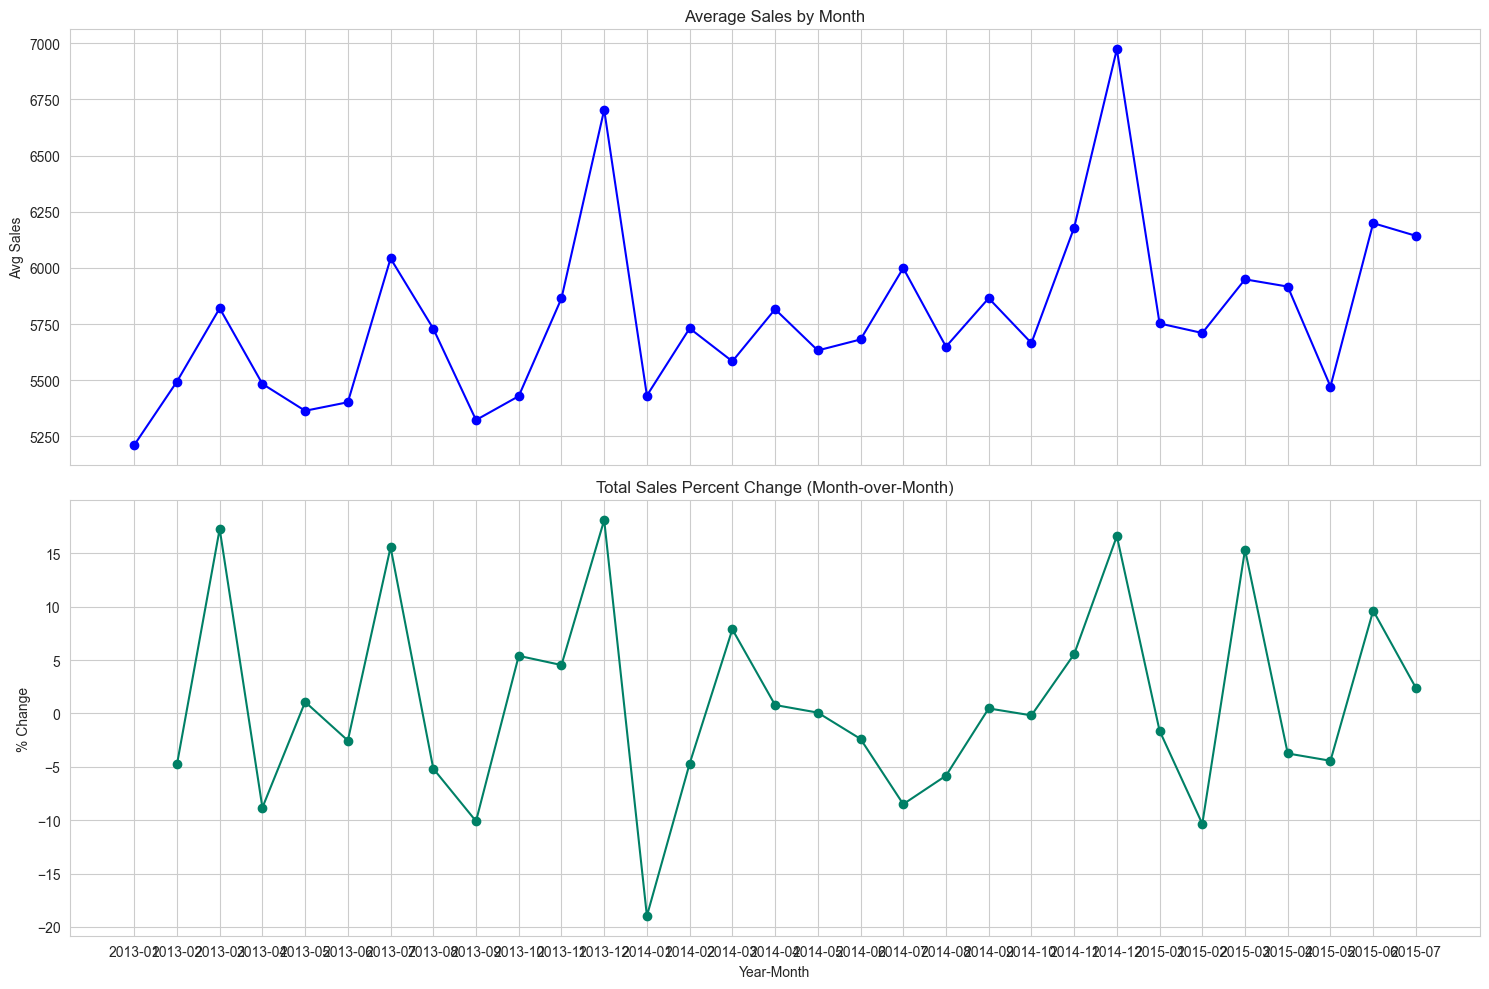

In [3]:
# Group by DateStr (Year-Month)
average_sales_time = df.groupby('DateStr')['Sales'].mean()
pct_change_sales_time = df.groupby('DateStr')['Sales'].sum().pct_change() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(15, 10))

# Plot average sales over time
average_sales_time.plot(ax=ax1, marker='o', title="Average Sales by Month", color='b')
ax1.set_ylabel("Avg Sales")
ax1.set_xticks(range(len(average_sales_time)))
ax1.set_xticklabels(average_sales_time.index.tolist(), rotation=90)

# Plot percent change over time
pct_change_sales_time.plot(ax=ax2, marker='o', colormap="summer", title="Total Sales Percent Change (Month-over-Month)")
ax2.set_ylabel("% Change")
ax2.set_xlabel("Year-Month")
plt.tight_layout()
plt.show()

**Insight**: There is a clear seasonality in sales. Late-year months (November, December) typically see a sharp spike in average sales due to the holiday season, often resulting in high positive percent changes. Post-holiday months (January) see massive drop-offs, marking the lowest sales volume of the cycle.

## 2. Day of Week Insights
Let's look at average sales by day of the week and compare it to the overall average.

Overall Average Sales: 5773.82

         Average Sales  % Change from Overall Avg
DayName                                          
Mon            7809.04                      35.25
Tue            7005.24                      21.33
Wed            6555.88                      13.55
Thu            6247.58                       8.21
Fri            6723.27                      16.44
Sat            5847.56                       1.28
Sun             204.18                     -96.46


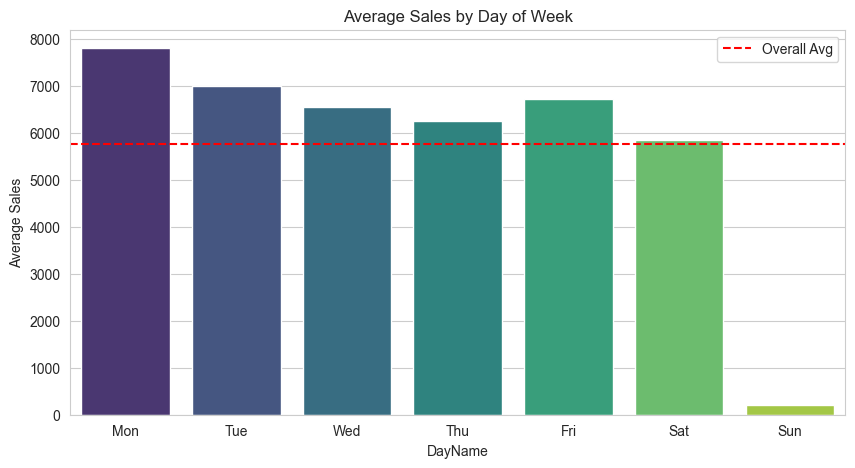

In [4]:
overall_mean_sales = df['Sales'].mean()
print(f"Overall Average Sales: {overall_mean_sales:.2f}\n")

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_stats = df.groupby('DayName')['Sales'].mean().reindex(day_order)
day_changes = (day_stats - overall_mean_sales) / overall_mean_sales * 100

insights_day = pd.DataFrame({
    'Average Sales': day_stats,
    '% Change from Overall Avg': day_changes
})
print(insights_day.round(2))

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=day_stats.index, y=day_stats.values, palette='viridis')
plt.axhline(overall_mean_sales, color='red', linestyle='--', label='Overall Avg')
plt.title("Average Sales by Day of Week")
plt.ylabel("Average Sales")
plt.legend()
plt.show()

**Insight**: Mondays have the highest sales on average, experiencing a **35.25%** increase compared to the overall average. Sundays face a massive drop of **96.46%** since most stores are closed.

## 3. Promotional Insights
How much do promotions actually increase sales?

Average Sales without Promo: 4406.05
Average Sales with Promo: 7991.15

Sales Increase due to Promotions: 81.37%


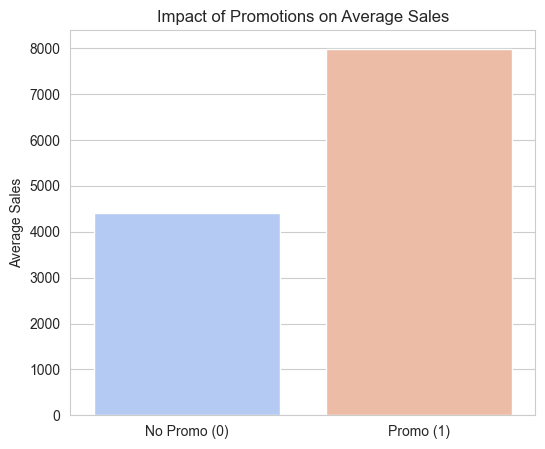

In [5]:
promo_stats = df.groupby('Promo')['Sales'].mean()
promo_increase = (promo_stats[1] - promo_stats[0]) / promo_stats[0] * 100

print(f"Average Sales without Promo: {promo_stats[0]:.2f}")
print(f"Average Sales with Promo: {promo_stats[1]:.2f}")
print(f"\nSales Increase due to Promotions: {promo_increase:.2f}%")

# Visualization
plt.figure(figsize=(6, 5))
sns.barplot(x=['No Promo (0)', 'Promo (1)'], y=promo_stats.values, palette='coolwarm')
plt.title("Impact of Promotions on Average Sales")
plt.ylabel("Average Sales")
plt.show()

**Insight**: Running a promotion increases an individual store's sales by **81.37%** on average. Promotions are highly effective and should be targeted during naturally slower mid-week days (Wednesday, Thursday) to lift overall volume.

## 4. Store Type Insights
Which store types perform the best?

           Average Sales  % Change from Overall Avg
StoreType                                          
a                5738.18                      -0.62
b               10058.84                      74.21
c                5723.63                      -0.87
d                5641.82                      -2.29


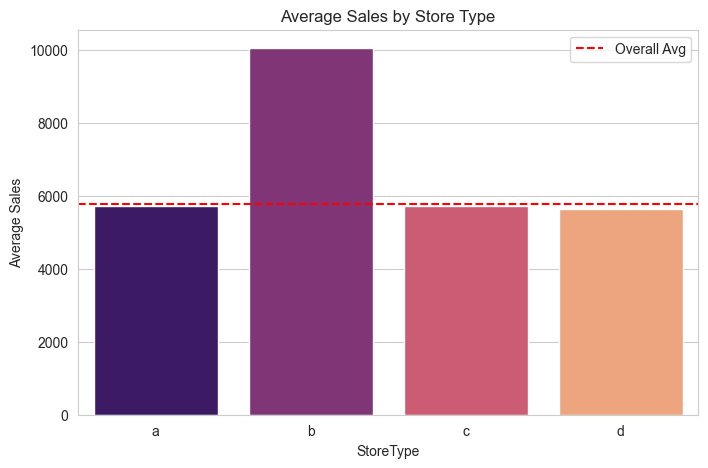

In [6]:
store_stats = df.groupby('StoreType')['Sales'].mean()
store_changes = (store_stats - overall_mean_sales) / overall_mean_sales * 100

insights_store = pd.DataFrame({
    'Average Sales': store_stats,
    '% Change from Overall Avg': store_changes
})
print(insights_store.round(2))

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x=store_stats.index, y=store_stats.values, palette='magma')
plt.axhline(overall_mean_sales, color='red', linestyle='--', label='Overall Avg')
plt.title("Average Sales by Store Type")
plt.ylabel("Average Sales")
plt.legend()
plt.show()

**Insight**: Store Type **b** dramatically outperforms the rest, seeing a **74.21%** positive difference from the overall average sales. Conversely, Store Type **d** trails slightly below average by **2.29%**.

## 5. Assortment Type Insights
Does the variety of items offered (Assortment level) impact sales?

            Average Sales  % Change from Overall Avg
Assortment                                          
a                 5481.03                      -5.07
b                 8553.93                      48.15
c                 6058.68                       4.93


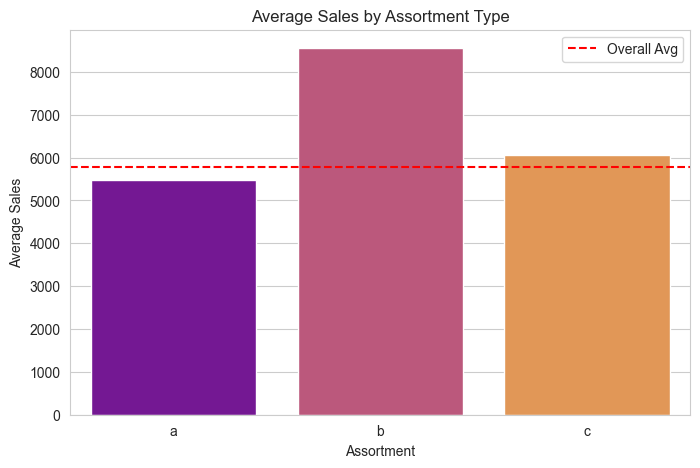

In [7]:
assort_stats = df.groupby('Assortment')['Sales'].mean()
assort_changes = (assort_stats - overall_mean_sales) / overall_mean_sales * 100

insights_assort = pd.DataFrame({
    'Average Sales': assort_stats,
    '% Change from Overall Avg': assort_changes
})
print(insights_assort.round(2))

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x=assort_stats.index, y=assort_stats.values, palette='plasma')
plt.axhline(overall_mean_sales, color='red', linestyle='--', label='Overall Avg')
plt.title("Average Sales by Assortment Type")
plt.ylabel("Average Sales")
plt.legend()
plt.show()

**Insight**: Stores offering "extra" assortment (Type **b**) dominate the sales numbers, averaging **48.15%** higher than the overall average sales! Assortment types 'a' and 'c' perform near or slightly below average.

## 6. Holiday Impacts (State vs School)
Do holidays spell a boom or bust for Rossmann sales?

              Avg Sales (State Holiday)  % Change
StateHoliday                                     
0                               5947.48      3.01
a                                290.74    -94.96
b                                214.31    -96.29
c                                168.73    -97.08

               Avg Sales (School Holiday)  % Change
SchoolHoliday                                      
0                                 5620.98     -2.65
1                                 6476.52     12.17


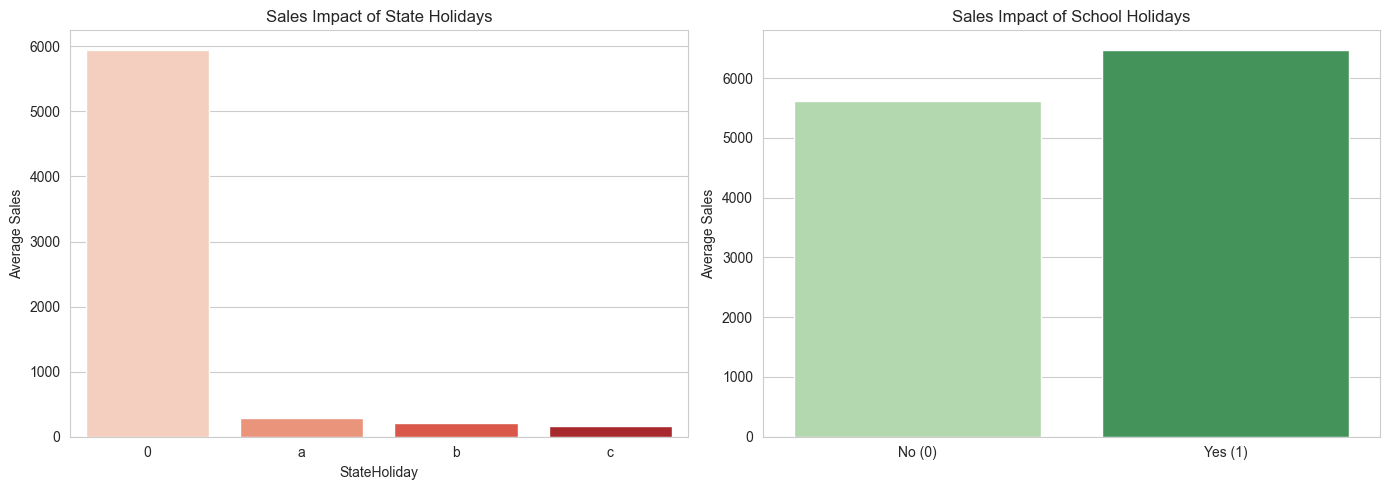

In [8]:
hol_stats = df.groupby('StateHoliday')['Sales'].mean()
hol_changes = (hol_stats - overall_mean_sales) / overall_mean_sales * 100

print(pd.DataFrame({'Avg Sales (State Holiday)': hol_stats, '% Change': hol_changes}).round(2))
print()

sh_stats = df.groupby('SchoolHoliday')['Sales'].mean()
sh_changes = (sh_stats - overall_mean_sales) / overall_mean_sales * 100

print(pd.DataFrame({'Avg Sales (School Holiday)': sh_stats, '% Change': sh_changes}).round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=hol_stats.index, y=hol_stats.values, ax=ax1, palette='Reds')
ax1.set_title('Sales Impact of State Holidays')
ax1.set_ylabel('Average Sales')

sns.barplot(x=['No (0)', 'Yes (1)'], y=sh_stats.values, ax=ax2, palette='Greens')
ax2.set_title('Sales Impact of School Holidays')
ax2.set_ylabel('Average Sales')

plt.tight_layout()
plt.show()

**Insight**: 
- **State Holidays** are a massive hit to sales. Almost identical to Sundays, sales drop by **94% to 97%** indicating that most stores close.
- **School Holidays**, on the other hand, provide a nice lift! When schools are on holiday, average sales see a **12.17%** increase above average, making it an excellent time to capitalize on foot traffic.

### Comparing State Holiday Types
Let's break down the state holidays to see if certain types of holidays impact sales more severely than others:
- **a** = Public holiday
- **b** = Easter holiday
- **c** = Christmas

              Avg Sales
StateHoliday           
a                290.74
b                214.31
c                168.73


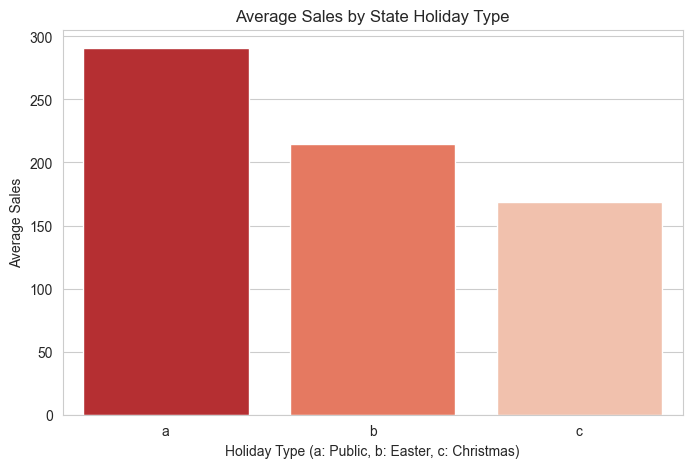

In [9]:
# Filter only actual state holidays
state_hol_types = df[df['StateHoliday'].isin(['a', 'b', 'c'])]
sht_stats = state_hol_types.groupby('StateHoliday')['Sales'].mean()

print(pd.DataFrame({'Avg Sales': sht_stats}).round(2))

plt.figure(figsize=(8, 5))
sns.barplot(x=sht_stats.index, y=sht_stats.values, palette='Reds_r')
plt.title('Average Sales by State Holiday Type')
plt.ylabel('Average Sales')
plt.xlabel('Holiday Type (a: Public, b: Easter, c: Christmas)')
plt.show()

**Insight**: All types of State Holidays trigger an enormous drop in sales. However, **Christmas (Type c)** sees the absolute lowest average sales (168.73), followed by **Easter (Type b)** (214.31). **Public holidays (Type a)** perform slightly better but still reflect massive drops compared to regular operating days.

## 7. Combined Effect of School Holiday and Promo
Does running a promotion during a school holiday yield a compound positive effect?

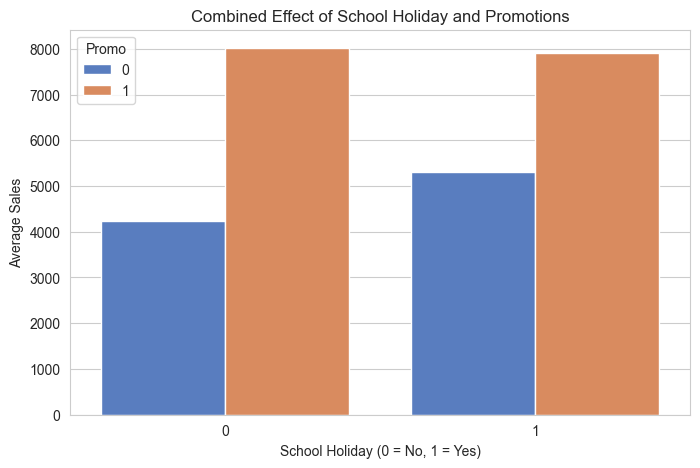

In [10]:
combo_stats = df.groupby(['SchoolHoliday', 'Promo'])['Sales'].mean().reset_index()

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(data=combo_stats, x='SchoolHoliday', y='Sales', hue='Promo', palette='muted')
plt.title("Combined Effect of School Holiday and Promotions")
plt.xlabel("School Holiday (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")
plt.show()

**Insight**: Yes! The combination of a Promo and a School Holiday results in the highest average sales overall. Store traffic is naturally elevated during holidays, and targeted promotions capitalize beautifully on this surge.

## 8. Month-wise Pattern of School Holidays and Orders
How are school holidays distributed throughout the year, and how do they correlate with average sales in those months?

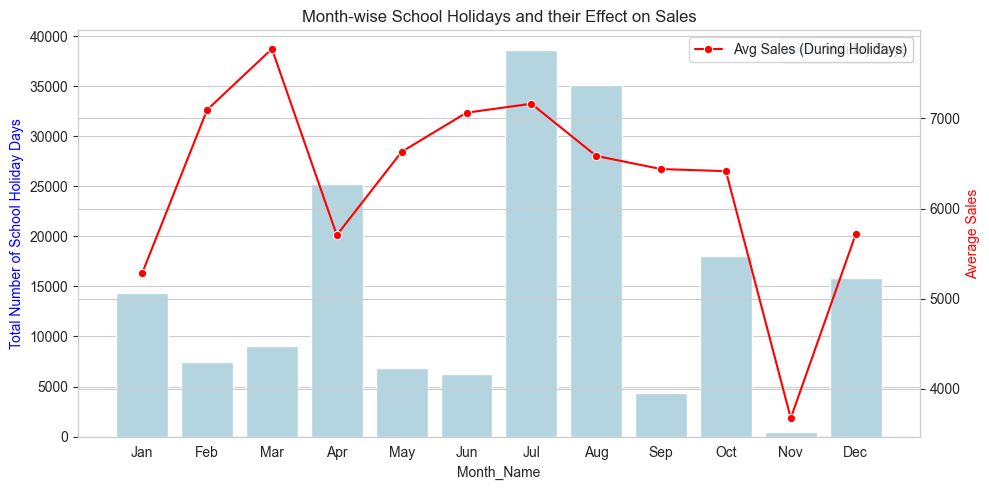

In [11]:
# Group by Month to get the frequency of School Holidays and average Sales
monthly_sh = df[df['SchoolHoliday'] == 1].groupby('Month_Name')['Sales'].agg(['count', 'mean']).reset_index()

# Reorder months logically
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sh['Month_Name'] = pd.Categorical(monthly_sh['Month_Name'].str[:3], categories=month_order, ordered=True)
monthly_sh = monthly_sh.sort_values('Month_Name')

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart for the number of school holiday days
sns.barplot(data=monthly_sh, x='Month_Name', y='count', ax=ax1, color='lightblue', label='Holiday Days')
ax1.set_ylabel("Total Number of School Holiday Days", color='blue')

# Line chart for the average sales during those holidays
ax2 = ax1.twinx()
sns.lineplot(data=monthly_sh, x='Month_Name', y='mean', ax=ax2, color='red', marker='o', label='Avg Sales (During Holidays)')
ax2.set_ylabel("Average Sales", color='red')

plt.title("Month-wise School Holidays and their Effect on Sales")
fig.tight_layout()
plt.show()

**Insight**: School Holidays are heavily concentrated in July and August (Summer break) as well as October and December. Interestingly, despite July and August having the most holiday days, the highest average sales *during* a school holiday occur heavily in December and post-Easter spring breaks.

## 9. Month-wise Pattern of Promotions
Are promotions run evenly throughout the year, and how do they impact monthly sales?

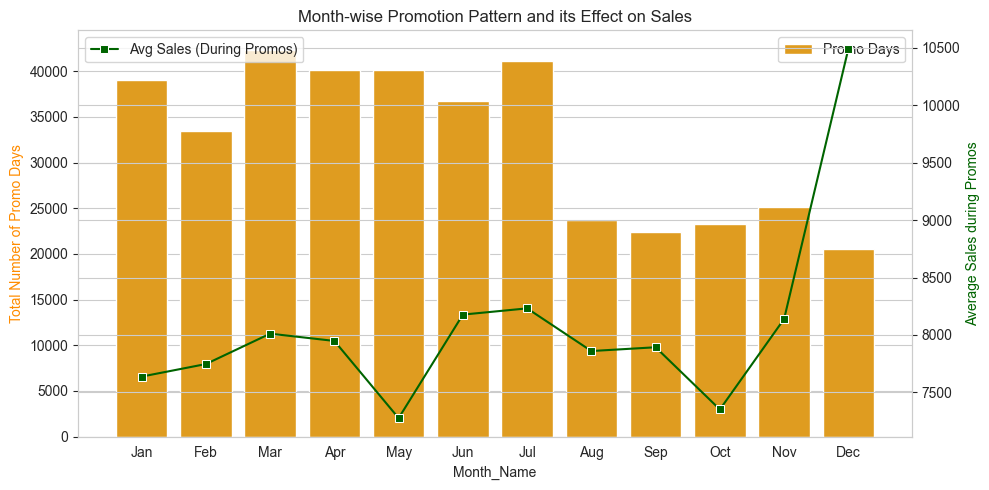

In [12]:
# Group by Month to get the frequency of Promotions and average Sales
monthly_promo = df[df['Promo'] == 1].groupby('Month_Name')['Sales'].agg(['count', 'mean']).reset_index()

# Reorder months logically
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_promo['Month_Name'] = pd.Categorical(monthly_promo['Month_Name'].str[:3], categories=month_order, ordered=True)
monthly_promo = monthly_promo.sort_values('Month_Name')

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart for the number of promotion days
sns.barplot(data=monthly_promo, x='Month_Name', y='count', ax=ax1, color='orange', label='Promo Days')
ax1.set_ylabel("Total Number of Promo Days", color='darkorange')

# Line chart for the average sales during those promos
ax2 = ax1.twinx()
sns.lineplot(data=monthly_promo, x='Month_Name', y='mean', ax=ax2, color='darkgreen', marker='s', label='Avg Sales (During Promos)')
ax2.set_ylabel("Average Sales during Promos", color='darkgreen')

plt.title("Month-wise Promotion Pattern and its Effect on Sales")
fig.tight_layout()
plt.show()

**Insight**: Promotions are run fairly consistently across all months. However, the *effectiveness* of promotions (average sales) skyrockets in November and December. This indicates that while promotional frequency is steady, customer responsiveness to promos is heavily dependent on the holiday shopping season!